# makemore_MLP

## some explanation before experiment

### Embedding Lookup Table `C`

- `C` is a **(vocab_size, embedding_dim)** matrix.
- Each row is a **learned vector** representing one character.
- `C[X]` performs a **table lookup**: replaces each integer index with its row from `C`.

#### Why 30 input neurons? (Karpathy's implementation)

Karpathy uses a smaller version of Bengio et al. 2003 for demonstration:

| | Bengio 2003 paper | Karpathy's implementation |
|---|---|---|
| Vocabulary | ~17k words | 27 chars (a-z + `.`) |
| Embedding dim | **30** per word | **10** per char |
| Context length | 3 words | 3 chars (block_size) |
| Total input | 3 × 30 = **90** | 3 × 10 = **30** |

In the Bengio paper diagram: each of the 3 inputs has 30 features → 90 neurons feeding into the hidden layer. Karpathy scales it down to 10 per character → 30 total, same idea.

#### Embedding as encoding

- **One-hot**: sparse, fixed, human-designed (27 dims per char → 81 dims for 3 chars).
- **Embedding**: dense, **learned from data**, compact (10 dims per char → 30 dims for 3 chars).
- Similar characters end up with similar vectors because the loss pushes them that way.

#### The embedding dimension is a hyperparameter

There's no special meaning to 10 dimensions (or 30 in Bengio's paper). We could pick 5, 10, 20, or 50. Larger dimensions give each character more expressive power, but also more parameters.

## preparation

In [296]:
# just copy these three cells right below from last lecture
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [297]:
words = open('../names.txt', 'r').read().splitlines()

In [298]:
from string import ascii_lowercase
stoi = {c:i+1 for i, c in enumerate(ascii_lowercase)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}

## building an MLP with a 3-character context

In [299]:
# build the dataset(similar to the way in lec02)

block_size = 3    # context length: the number of characters that we need to used in prediction.
inputs, labels = [], []

# just use 5 words to present
# the code is similar to lec02
for w in words[:5]:
    print(w)
    context = [0] * block_size
    chs = w + '.'
    for ch in chs:
        inputs.append(context)
        labels.append(stoi[ch])
        print(f"{''.join(itos[i] for i in context)} ---> {ch}")
        context = context[1:] + [stoi[ch]]

inputs = torch.tensor(inputs)
labels = torch.tensor(labels)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [300]:
# Initialize the look-up table C
# We just create 2-dimensional embedding vectors here for each character.
C = torch.randn(27, 2)

In [301]:
# C[inputs] means indexing C by every context in inputs.
# It's a multiple version of integer index(C[integer]).
C[inputs].shape

# shape(32, 3, 2):
# 32 means 32 inputs which split from 5 words;
# 3 means context length;
# 2 means the number of dimensions of embedding vectors which we set before.

# Or we can view the 32 inputs as 32 blocks, each indexed by the initial embedding matrix C.
# Each block has a shape of (3, 2),
# meaning that each input (i.e., context) has a context length of 3,
# and each context (i.e., each input character) corresponds to a 2-dimensional embedding vector.

torch.Size([32, 3, 2])

In [302]:
# create weights, biases, and 100 neurons in hidden layer
W1 = torch.randn(6, 100)
B1 = torch.randn(100)

# Since the shape of emb can't perform matrix multiplication with weights，we should do transformation.

In [303]:
emb = C[inputs]
# This index will index all the 2 embedding vectors of 32 inputs of first context character.
emb[:, 0, :].shape

torch.Size([32, 2])

In [304]:
# torch.cat can concatenate tensors on the specified dimension.
# This operation will create a whole new tensor which has whole new storage. It's inefficient.
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape

torch.Size([32, 6])

In [305]:
# torch.unbind can remove the specified dimension from a tensor
# and return several slices resulting from the dimension reduction.

# These operations have the same effect as the cell right above.
# But this is more flexible when changing the context length.
torch.cat(torch.unbind(emb, dim=1), dim=1).shape

torch.Size([32, 6])

In [306]:
# torch.view can return a view by specified shape from tensor.
# This way can also do the same thing like two methods do above but faster than them.
# You can try to use `==` to verify equivalence of these methods.
# About the reasons or mechanisms, you can read the blog that karpathy mentioned in the video or STFW/RTFM/ATFA(ask the 'friendly' AI).
emb.view(32, 6).shape

torch.Size([32, 6])

In [307]:
# so that we can do matrix multiplication and build hidden layer with activation function tanh.

# We can also use `-1` to let pytorch derive the number or shape automatically.(i.e., `emb.view(-1, 6)`)

# The reason why we use tanh here is to：
# 1. break linear: When performing computations in the next layer, linear operations are also required.
#                  If the activation function is linear,the associativity of matrix multiplication causes the weights and biases from all previous layers to be treated as a single layer.
#                  Therefore, a nonlinear activation function must be used to ensure that the parameters and weights from the previous layer are not disrupted.
# 2. historical precedent: this is how the activation functions for hidden layers were set up in bengio's time.
hl = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + B1)

hl.shape

torch.Size([32, 100])

In [308]:
# create weights, biases, and 27 neurons in next layer.
W2 = torch.randn(100, 27)
B2 = torch.randn(27)

In [309]:
# create logits
logits = hl @ W2 + B2

In [310]:
# Do the similar softmax function on logits.
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
probs.shape

torch.Size([32, 27])

In [311]:
# evaluate the loss
loss = probs[torch.arange(32), labels].log().neg().mean()
loss

tensor(12.9040)

In [312]:
# PyTorch already has the cross_entropy function to calculate loss(or as loss function) by using logits and labels.
F.cross_entropy(logits, labels)

# We always use wrapped functions in practice. The reasons:
# 1.Fused operations use fused kernels, that will be faster.
#   Fused kernels are computed only once during backpropagation,
#   unlike separate operations, which are computed multiple times.
#   For example, in lec01, if the tanh function is not implemented separately,
#   multiple different operations would be required for backpropagation.
# 2.It is well-behaved(Numerical Stability).
#   For example, in exponential functions, when the input number is too large, the data will overflow and result in an "inf" value.
#   PyTorch automatically applies some offsets during computation to ensure the data is processed correctly.
#   For a detailed explanation, please attend the lecture.

tensor(12.9040)

In [313]:
# I use the code in '## build complete MLP' to train the model which just inputs 5 words and put the result here.

# It's an overfit training. Because we use a bunch of parameters to predict just 5 words.
# The loss will never go to zero because '...', the prefix of first character, will be predicted to different characters by model.
# But we still end up with a pretty close prediction.
loss, logits.max(1), labels

(tensor(12.9040),
 torch.return_types.max(
 values=tensor([13.5582,  7.4582, 14.9314, 12.2689, 10.2038, 13.5582, 15.1759, 13.1738,
         17.4270, 12.5768, 10.7179, 10.3846, 13.5582,  8.3489,  9.4293, 10.9365,
         13.5582,  8.2047, 13.4814, 19.2004, 14.8048, 11.4623, 12.8208, 11.2391,
         14.9415, 13.5582, 10.8588, 19.0877, 13.2656, 12.9478, 23.0166, 20.9232]),
 indices=tensor([19, 10, 25,  5, 21, 19, 19, 15, 11,  2, 13, 25, 19, 13, 10, 13, 19, 13,
         10,  7,  5,  1, 10,  3,  7, 19, 15, 11,  5, 15, 11,  5])),
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

## build complete MLP

In [319]:
# build dataset
block_size = 3    # context length
inputs, labels = [], []

for w in words:
    context = [0] * block_size
    chs = w + '.'
    for ch in chs:
        inputs.append(context)
        labels.append(stoi[ch])
        context = context[1:] + [stoi[ch]]

inputs = torch.tensor(inputs)
labels = torch.tensor(labels)

In [320]:
# initialize the tensors in need
g = torch.Generator().manual_seed(2147483647)    # for reproducibility

emb_dim = 20    # demension of embedding vectors
ns_num_h = 300    # the number of neurons in hidden layer

C = torch.randn(27, emb_dim, generator=g, requires_grad=True)
W1 = torch.randn(block_size * emb_dim , ns_num_h, generator=g, requires_grad=True)
B1 = torch.randn(ns_num_h, generator=g, requires_grad=True)
W2 = torch.randn(ns_num_h, 27, generator=g, requires_grad=True)
B2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, B1, W2, B2]

In [321]:
sum([p.numel() for p in parameters])

26967

In [322]:
# Initialize the searching space of learning rate.
# lre = torch.linspace(-3, 1, 50000)
# lrs = 10**lre
# lri = []
# lossi = []
# stepi = []

In [323]:
# training loop

# use training set to train model
for k in range(1000000):
    
    # mini-batch
    # ix = torch.randint(0, inputs.shape[0], (32,))
    ix = torch.randint(0, Xtrain.shape[0], (128,))

    # forward pass
    # emb = C[inputs[ix]]
    emb = C[Xtrain[ix]]
    hl = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + B1)
    logits = hl @ W2 + B2
    # loss = F.cross_entropy(logits, labels[ix])
    loss = F.cross_entropy(logits, Ytrain[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += p.grad * (-0.1 if k < 500000 else -0.03)

    # update with searching learning rate
    # lr = lrs[k]
    # for p in parameters:
    #     p.data += -lr * p.grad
    # lri.append(lr.log10().item())
    # lossi.append(loss.item())
    # stepi.append(k)

    # print(f"learning rate:{lr:.4f}")
    # print(f"round:{k}, loss:{loss:.4f}")

In [324]:
# check the loss of whole model
# use dev set to evaluate model
# emb = C[inputs]
emb = C[Xdev]
hl = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + B1)
logits = hl @ W2 + B2
# loss = F.cross_entropy(logits, labels)
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.1463053226470947

## optimization

You can uncomment the code in the training loop above when an optimization method below is learned.

### batched training

In [315]:
# The training right above is too slow because we're feeding the model over 22,800 inputs,
# and each iteration involves an extremely large number of computations.

# We will use mini-batch which is a random sample from whole inputs to train the model little by little.

# But if we use mini-batch to train the model, the accuracy of gradient of model will decrease.
# Mini-batch can introduce some noise.
# This is because we don't use the entire input set, but only a portion of it.
# However, rather than calculating the exact gradient by using the full input, 
# the approximate gradient obtained by training the model incrementally using mini-batches can also gradually reduce the loss to achieve the desired result—and it's much faster.
# This represents a trade-off between practical engineering and mathematical ideals.

# We use randint to randomly generate mini-batches(actually it's the indices of inputs and labels)
# inputs.shape[0] means the number of inputs.
torch.randint(0, inputs.shape[0], (32,))

tensor([ 3, 19, 11, 21, 14,  4,  8, 12,  0, 11, 17, 14, 11, 26,  4,  9, 31,  7,
        10, 11, 31, 31,  5, 15, 18, 21, 13,  1, 16, 31, 20, 28])

### learning rate

In [316]:
# The basic way we set learning rate has already been discussed in lec01.
# Here is the method of finding an appropriate learning rate.

# Learning rates are typically searched on an exponential (logarithmic) scale rather than a linear scale.
# Reasons:
# 1.The effective learning rate range often spans multiple orders of magnitude(e.g., 1e-6 ~ 1e-1), making linear search inefficient.
# 2.Learning rate controls the *scale* of parameter updates, so optimizers are much more sensitive to relative changes (×2, ×10) than absolute increments.
# 3.The training loss usually varies more smoothly with log(lr), making it easier to identify a suitable learning rate.
# Therefore, learning rates are commonly searched using exponential progression,
# for example: 1e-6 → 1e-5 → 1e-4 → 1e-3 → 1e-2 → 1e-1
# In engineering, it is common to start the search with an exponential base of 10, and then reduce the base (for example, to 3 or 2) only when the model requires a more precise learning rate.

# generate the index of exponential(the searching space)
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

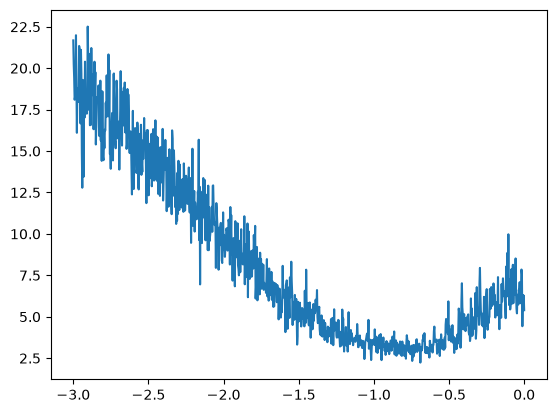

In [ ]:
# showing the relationship between the learning rate (on a logarithmic scale) and the loss.
# We can find better learning rate is near 0.1 (10^-1).
# We can also use learning rate decay which have learned in lec01, i.e. `lr = 0.1 - 0.09 * k / 30000`.
plt.plot(lri, lossi)

### split dataset

Typically, a dataset is split into three parts: Training set (80%), Development/Validation set (10%), and Test set (10%).

- Training set: Used to train the model's weights via backpropagation.

- Dev/Validation set: Used to evaluate the model's performance (by calculating the loss) during development. Based on these results, we tune the hyperparameters and retrain the model on the training set.

- Test set: Used strictly for final evaluation to check if the model's outputs meet expectations. Never use the test loss to tweak the model—doing so introduces data leakage, essentially turning your test set into another training set."


In practice, **diagnosing whether a model is underfitting, well-fit, or overfitting** boils down to the following rules:

- If dev loss is still decreasing: Keep training. Don't worry about how low the training loss gets.

- If dev loss stops decreasing (plateaus): Stop training immediately (Early Stopping), regardless of whether the training loss continues to drop.

- If the gap between training and dev loss widens (i.e., training loss drops while dev loss rises): This is a classic signal of overfitting. However, your ultimate basis for decision-making should always be the trajectory of the dev loss.

As for the test set, it is held out and used only after all training and tuning are complete, serving as a final check to see if the model genuinely produces the expected outputs and for final performance evaluation.

In [167]:
# build and split the dataset
block_size = 3

def build_dataset(words):  
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# randomly split dataset into 3 splits
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtrain, Ytrain = build_dataset(words[:n1])    # 80% training set
Xdev, Ydev = build_dataset(words[n1:n2])      # 10% dev set
Xtest, Ytest = build_dataset(words[n2:])      # 10% test set

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [317]:
print(n1, n2-n1, len(words)-n2)
# back to taining loop to see the performance

25626 3203 3204


## some plots

In [ ]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
# for example, for 'a','e','i','o','u', their embedding vectors are relatively close to each other,
# so the model considers their roles to be similar and believes they can be interchangeable.

In [ ]:
# the relationship between training turn and loss
plt.plot(stepi, lossi)

## sample from model

In [325]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    outs = []
    context = [0] * block_size
    while True:
        # same as training
        # just need to notice that you should keep the input shape the same as during training
        embt = C[torch.tensor([context])]
        hlt = torch.tanh(embt.view(-1 ,block_size * emb_dim) @ W1 + B1)
        logits = hlt @ W2 + B2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        outs.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0: break
    print(''.join(outs))


carmah.
amillivia.
jari.
reet.
khalaysie.
rahmeeder.
sart.
kaeli.
nellara.
chriha.
